In [ ]:
# Run this setup cell first — everything today depends on it
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All imports successful. Let's build some trees!")

All imports successful. Let's build some trees!


**What is a Decision Tree?**

Imagine a doctor who has seen 1000 patients. She learned to diagnose by asking questions in the right order:

Does the patient have a fever? --> Yes --> Is the fever above 39c --> yes --> likely infection.

Does the patient have a fever? --> No --> Any cough --> No --> Probably fine

That branching question structure is a decision tree. The doctor learned which questions to ask first by figuring out which questions eliminate uncertainty the fastest.

In ML the questions are feature thresholds: "Is feature X>3.5?". The tree learns which feature and which threshold to split on at each step.

A decision tree learns a sequence of yes/no questions that best separate te classes.

**How does the tree decide where to split?**

The tree needs a way to measure "how mixed up" a node is. Two measurements exist:

1. Gini Impurity, How often would you missclassify a random sample?
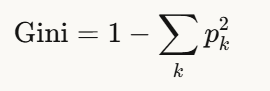

The Analogy, A bag of coloured balls:

Imagine a bag with balls. you pick one ball, put it back, pick another. Gini impurity=probability the two balls are different colours.

Pure bag(all red): Gini=0,perfect, no surprise.

Half red, half blue: Gini=0.5, maximum confusion.

The tree wants to create bags that are as pure as possible.

2. Entropy and Info gain, How surprised are you by the outcome.
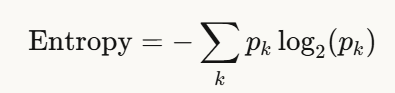

The Analogy, A weather forecast:

In a city where it rains 50% of the time, you are always surprised by tomorrow's weather, high entropy. In a city where it rains 99% of the time, you are almost never surprised, low entropy.

The tree wants each split to reduce surprise as much as possible. that reduction is called Info gain.

Information Gain=Entropy(parent)−weighted average Entropy(children)



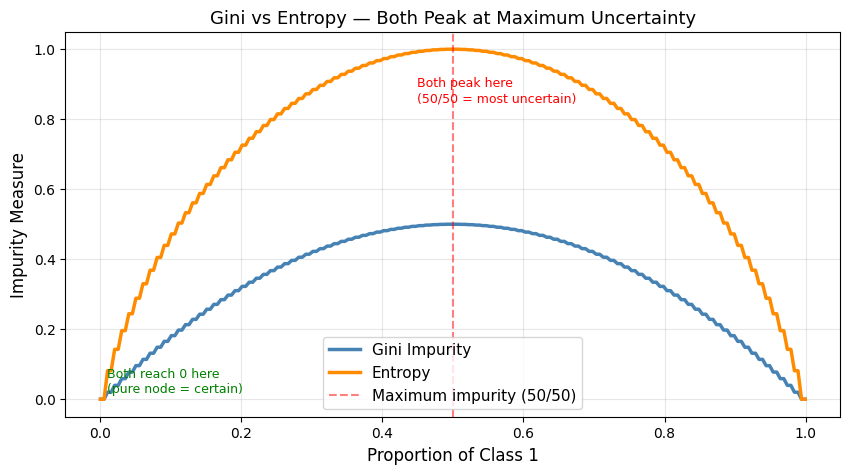

KEY INSIGHT:
Gini and Entropy almost always choose the SAME split.
Gini is slightly faster to compute (no log).
Entropy is slightly more sensitive to class imbalance.
In practice: both give nearly identical trees.


In [ ]:
def gini_impurity(y):
  """
  How impure is this node?
  0=perfectly pure(all one class)
  0.5=max impuirty (50/50 split, binary case)

  """

  if len(y)==0:
    return 0
  classes, counts=np.unique(y, return_counts=True)
  probabilities=counts/len(y)
  return 1-np.sum(probabilities**2)

def entropy(y):
  """
  How much uncertainty exists in this node?
  0=perfect certain(all one class)
  1=maximum uncertainty(50/50 split, binary case)
  """
  if len(y)==0:
    return 0
  classes, counts=np.unique(y, return_counts=True)
  probabilities=counts/len(y)
  #Avoid log(0) by filtering zero probabilities
  probabilities=probabilities[probabilities>0]
  return -np.sum(probabilities*np.log2(probabilities))

  def information_gain(y_parent, y_left, y_right):
    """
    How much did this split reduce uncertainty?
    Higher=Better Split
    """

    n=len(y_parent)
    n_left, n_right=len(y_left), len(y_right)

    #weighted average entropy of children
    weighted_child_entropy=(
        (n_left/n)*entropy(y_left)
        +(n_right/n)*entropy(y_right
    ))
    return entropy(y_parent)-weighted_child_entropy

# ── Visualise how Gini and Entropy change with class balance ──
proportions = np.linspace(0.001, 0.999, 200)
gini_values    = [gini_impurity(
    np.array([1]*int(p*100) + [0]*int((1-p)*100))) for p in proportions]
entropy_values = [entropy(
    np.array([1]*int(p*100) + [0]*int((1-p)*100))) for p in proportions]

plt.figure(figsize=(10, 5))
plt.plot(proportions, gini_values,
         color='steelblue', linewidth=2.5, label='Gini Impurity')
plt.plot(proportions, entropy_values,
         color='darkorange', linewidth=2.5, label='Entropy')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5,
            label='Maximum impurity (50/50)')
plt.xlabel("Proportion of Class 1", fontsize=12)
plt.ylabel("Impurity Measure", fontsize=12)
plt.title("Gini vs Entropy — Both Peak at Maximum Uncertainty",
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.annotate("Both reach 0 here\n(pure node = certain)",
             xy=(0.01, 0.02), fontsize=9, color='green')
plt.annotate("Both peak here\n(50/50 = most uncertain)",
             xy=(0.45, 0.85), fontsize=9, color='red')
plt.show()

print("KEY INSIGHT:")
print("Gini and Entropy almost always choose the SAME split.")
print("Gini is slightly faster to compute (no log).")
print("Entropy is slightly more sensitive to class imbalance.")
print("In practice: both give nearly identical trees.")

Build DT from scratch

In [ ]:
class DecisionTreeFromScratch:
    """
    A complete decision tree classifier built from nothing.
    Read every method carefully — this IS the algorithm.
    """
    #Step 1
    def __init__(self, max_depth=None, min_samples_split=2,
                 criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.tree = None
    #I am creating a dt with some rules:
    #max_depth: Dont ask more than X questiond deep(prevents overfitting)
    #min_samples_split: Dont split if you have fewer than 2 examples
    #criterion: Use Gini or entropy to measure how 'mized up' my groups are
    #tree: I will store my final tree here(currently empty)

    def _impurity(self, y):
        """Calculate impurity based on chosen criterion"""
        if self.criterion == 'gini':
            return gini_impurity(y)
        else:
            return entropy(y)

    def _best_split(self, X, y):
        """
        THE CORE ALGORITHM.
        Try EVERY feature and EVERY possible threshold.
        Return the split that reduces impurity the most.
        """
        best_gain = -np.inf
        best_feature = None
        best_threshold = None
        parent_impurity = self._impurity(y)

        n_samples, n_features = X.shape

        for feature_idx in range(n_features):
            #I am going to tru every possible question I could ask:
            #Is age < 25->split data, measure mprovement
            #..and so on for every feature and every value
            #the i pick the question that separates the classes best
            # Get all unique values as candidate thresholds
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                # Split data based on this threshold
                left_mask  = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                # Skip if split creates empty node
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left  = y[left_mask]
                y_right = y[right_mask]
                n = len(y)

                #How do we measure best?
                # Calculate information gain
                gain = parent_impurity - (
                    (len(y_left)/n)  * self._impurity(y_left) +
                    (len(y_right)/n) * self._impurity(y_right)
                )
                #How much did this question unmix my data?
                #parent_impurity: How mixed the data was before asking the question.
                #weighted avg after split: how mixed the data is After splitting
                #gain: The different=how much we improved
                #higher gain=better question

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        """
        Recursively build the tree.
        Stop when: max depth reached, too few samples,
                   or node is already pure.
        """
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # ── STOPPING CONDITIONS (when to make a leaf) ──
        if (
            (self.max_depth is not None and depth >= self.max_depth) or
            n_samples < self.min_samples_split or
            n_classes == 1  # Node is already pure!
        ):
            # Leaf node: predict the majority class
            leaf_value = np.bincount(y).argmax()
            return {'leaf': True, 'value': leaf_value,
                    'samples': n_samples,
                    'impurity': self._impurity(y)}

        # ── FIND BEST SPLIT ──
        #what is the best question I can ask right now?
        best_feature, best_threshold, best_gain = self._best_split(X, y)

        # If no beneficial split found, make a leaf
        if best_feature is None or best_gain <= 0:
            leaf_value = np.bincount(y).argmax()
            return {'leaf': True, 'value': leaf_value,
                    'samples': n_samples,
                    'impurity': self._impurity(y)}

        # ── SPLIT THE DATA AND RECURSE ──
        #split the data based on my best question:
        #left branch: All examples where the answer is YES(<=threshold)
        #Right branch: All examples where the anser is No(>threshold)
        #ten recursively build a tree for each side
        #for the yes group, what is the best next questions?
        #for the No group, what is the best next question?
        #keep doing this until we hit a stopping condition
        left_mask  = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'gain': best_gain,
            'samples': n_samples,
            'impurity': self._impurity(y),
            'left':  self._build_tree(X[left_mask],  y[left_mask],  depth+1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth+1)
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
      #for a new person, follow the trees questions:
      #start at the top
      #ask the question
      #if yes->go left, ask the next question there
      #if no->go right, ask the next question there
      #keep going until you hit a LEAF
      #The leaf tells you the predicted class
        """Traverse the tree for a single sample"""
        if node['leaf']:
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    def print_tree(self, node=None, depth=0, feature_names=None):
        """Pretty-print the tree so you can SEE the decisions"""
        if node is None:
            node = self.tree
        indent = "  " * depth
        if node['leaf']:
            print(f"{indent}→ PREDICT: Class {node['value']} "
                  f"(samples={node['samples']}, "
                  f"impurity={node['impurity']:.3f})")
        else:
            fname = (feature_names[node['feature']]
                     if feature_names else f"Feature[{node['feature']}]")
            print(f"{indent}IF {fname} <= {node['threshold']:.3f} "
                  f"(gain={node['gain']:.4f}, samples={node['samples']})")
            print(f"{indent}  [LEFT - YES]:")
            self.print_tree(node['left'], depth+2, feature_names)
            print(f"{indent}  [RIGHT - NO]:")
            self.print_tree(node['right'], depth+2, feature_names)

# ── Test it! ──
X, y = make_classification(n_samples=300, n_features=4,
                            n_informative=2, n_redundant=0,
                            random_state=42)
feature_names = ['Age', 'Income', 'Score', 'Tenure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train our from-scratch tree
scratch_tree = DecisionTreeFromScratch(max_depth=3, criterion='gini')
scratch_tree.fit(X_train, y_train)

print("🌳 OUR FROM-SCRATCH DECISION TREE:")
print("=" * 55)
scratch_tree.print_tree(feature_names=feature_names)

scratch_preds = scratch_tree.predict(X_test)
print(f"\n✅ From-Scratch Accuracy: {accuracy_score(y_test, scratch_preds):.4f}")

# Compare with sklearn (should be very similar!)
sklearn_tree = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                       random_state=42)
sklearn_tree.fit(X_train, y_train)
sklearn_preds = sklearn_tree.predict(X_test)
print(f"✅ Sklearn Accuracy:       {accuracy_score(y_test, sklearn_preds):.4f}")
print("\nThey should be very close — same algorithm, same idea!")


🌳 OUR FROM-SCRATCH DECISION TREE:
IF Tenure <= -0.174 (gain=0.3769, samples=240)
  [LEFT - YES]:
    IF Income <= 1.687 (gain=0.0059, samples=116)
      [LEFT - YES]:
        IF Tenure <= -0.405 (gain=0.0046, samples=107)
          [LEFT - YES]:
            → PREDICT: Class 0 (samples=93, impurity=0.000)
          [RIGHT - NO]:
            → PREDICT: Class 0 (samples=14, impurity=0.245)
      [RIGHT - NO]:
        IF Income <= 1.854 (gain=0.3457, samples=9)
          [LEFT - YES]:
            → PREDICT: Class 1 (samples=2, impurity=0.000)
          [RIGHT - NO]:
            → PREDICT: Class 0 (samples=7, impurity=0.000)
  [RIGHT - NO]:
    IF Tenure <= 0.244 (gain=0.0449, samples=124)
      [LEFT - YES]:
        IF Income <= 0.299 (gain=0.2755, samples=21)
          [LEFT - YES]:
            → PREDICT: Class 0 (samples=12, impurity=0.375)
          [RIGHT - NO]:
            → PREDICT: Class 1 (samples=9, impurity=0.000)
      [RIGHT - NO]:
        IF Age <= -0.221 (gain=0.0030, samples

**Explainhow dt wroks from scratch?**

A decision tree builds a flowchart of yes/no questions to classify data. The algorithm works in 3 steps:

1. Find the best split: for every feature and every possible threshold, calculate ow much splitting there reduces impurity(using gini or entropy). Pick the split with the highest info gain.

2. Recursively split: divide the data based on that best question. Then repeat the process on each subset, find the best split for the left group and find the best split for the right group, and so on.

3. Stop and done: Stop splitting when you hit a stopping condition: maximum depth reached, too few samples to split, or the node is already pure(all same class). These become leaf nodes that output a prediction.

For prediction: Start at the root, answer each question for the new data point, follow the corresponding branch, and return the class at the leaf node you land on. The key insight is that we are greedily choosing the best question at each step, we dont look ahead multiple levels. This amkes the also fast but can miss globally optimal solution.

In [ ]:
# ═══════════════════════════════════════════════════════
# DECISION TREE FROM SCRATCH - FULLY ANNOTATED
# ═══════════════════════════════════════════════════════

class DecisionTreeFromScratch:

    def __init__(self, max_depth=None, min_samples_split=2, criterion='gini'):
        # 📝 Set up the rules for our tree
        self.max_depth = max_depth              # "Don't go deeper than this"
        self.min_samples_split = min_samples_split  # "Need at least this many to split"
        self.criterion = criterion              # "Use Gini or Entropy"
        self.tree = None                        # "Tree will be built here"

    def _impurity(self, y):
        # 📊 "How mixed up are the classes in this group?"
        # Lower = better (more pure)
        if self.criterion == 'gini':
            return gini_impurity(y)  # Used by CART
        else:
            return entropy(y)        # Used by ID3/C4.5

    def _best_split(self, X, y):
        # 🎯 THE CORE: Find the BEST question to ask

        best_gain = -np.inf     # "Track the best improvement we've seen"
        best_feature = None     # "Which feature should we ask about?"
        best_threshold = None   # "What value should we compare against?"

        parent_impurity = self._impurity(y)  # "How mixed is the current group?"
        n_samples, n_features = X.shape

        # 🔁 Try EVERY possible question
        for feature_idx in range(n_features):  # For each feature...
            thresholds = np.unique(X[:, feature_idx])  # Get all unique values

            for threshold in thresholds:  # For each value...
                # ✂️ "What if we split here?"
                left_mask  = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                # ⚠️ Skip if split creates empty group (pointless)
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                # 📊 Calculate how much this split improves things
                y_left  = y[left_mask]
                y_right = y[right_mask]
                n = len(y)

                # Information Gain = Parent Impurity - Weighted Child Impurity
                gain = parent_impurity - (
                    (len(y_left)/n)  * self._impurity(y_left) +
                    (len(y_right)/n) * self._impurity(y_right)
                )

                # 🏆 "Is this the best split so far?"
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        # 🌲 Recursively build the tree

        n_samples = len(y)
        n_classes = len(np.unique(y))

        # 🛑 STOPPING CONDITIONS (when to make a LEAF)
        if (
            (self.max_depth is not None and depth >= self.max_depth) or  # Too deep
            n_samples < self.min_samples_split or                         # Too few samples
            n_classes == 1                                                # Already pure!
        ):
            # 🍃 Make a LEAF: predict the majority class
            leaf_value = np.bincount(y).argmax()  # Most common class
            return {
                'leaf': True,
                'value': leaf_value,      # "My answer is this class"
                'samples': n_samples,
                'impurity': self._impurity(y)
            }

        # 🔍 Find the best question to ask
        best_feature, best_threshold, best_gain = self._best_split(X, y)

        # 🛑 If no good split found, make a leaf
        if best_feature is None or best_gain <= 0:
            leaf_value = np.bincount(y).argmax()
            return {
                'leaf': True,
                'value': leaf_value,
                'samples': n_samples,
                'impurity': self._impurity(y)
            }

        # ✂️ SPLIT the data and RECURSE
        left_mask  = X[:, best_feature] <= best_threshold  # "YES answers"
        right_mask = ~left_mask                            # "NO answers"

        return {
            'leaf': False,
            'feature': best_feature,      # "Ask about this feature"
            'threshold': best_threshold,  # "Compare against this value"
            'gain': best_gain,
            'samples': n_samples,
            'impurity': self._impurity(y),
            'left':  self._build_tree(X[left_mask],  y[left_mask],  depth+1),  # Build left subtree
            'right': self._build_tree(X[right_mask], y[right_mask], depth+1)   # Build right subtree
        }

    def fit(self, X, y):
        # 🚀 "Build the tree!"
        self.tree = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        # 🔮 "Follow the tree for one data point"

        if node['leaf']:
            # 🍃 Reached a leaf — return the prediction!
            return node['value']

        # ❓ Ask the question at this node
        if x[node['feature']] <= node['threshold']:
            # YES → go left
            return self._predict_one(x, node['left'])
        else:
            # NO → go right
            return self._predict_one(x, node['right'])

    def predict(self, X):
        # 🔮 "Predict for all data points"
        return np.array([self._predict_one(x, self.tree) for x in X])

    def print_tree(self, node=None, depth=0, feature_names=None):
        # 🖨️ "Show me the tree visually"
        if node is None:
            node = self.tree

        indent = "  " * depth

        if node['leaf']:
            print(f"{indent}→ PREDICT: Class {node['value']} "
                  f"(samples={node['samples']}, impurity={node['impurity']:.3f})")
        else:
            fname = (feature_names[node['feature']]
                     if feature_names else f"Feature[{node['feature']}]")
            print(f"{indent}IF {fname} <= {node['threshold']:.3f} "
                  f"(gain={node['gain']:.4f}, samples={node['samples']})")
            print(f"{indent}  [LEFT - YES]:")
            self.print_tree(node['left'], depth+2, feature_names)
            print(f"{indent}  [RIGHT - NO]:")
            self.print_tree(node['right'], depth+2, feature_names)

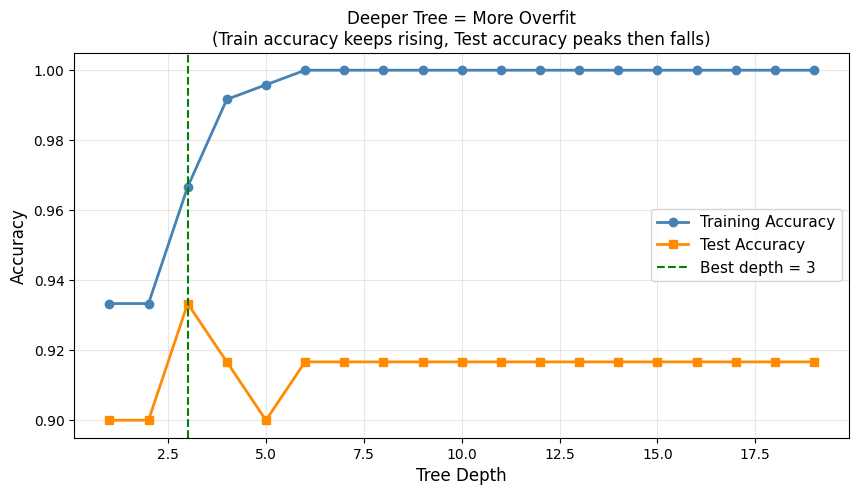

KEY INSIGHT:
A fully grown tree memorises training data perfectly (100% train acc)
But it fails on new data — it learned noise, not signal.
This is OVERFITTING. max_depth is the main control knob.


In [ ]:
#Overfitting in Trees
# The most important tree lesson: depth controls everything
train_scores, test_scores = [], []
depths = range(1, 20)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  tree.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', color='steelblue',
         linewidth=2, label='Training Accuracy')
plt.plot(depths, test_scores, 's-', color='darkorange',
         linewidth=2, label='Test Accuracy')
plt.axvline(depths[np.argmax(test_scores)], color='green',
            linestyle='--',
            label=f'Best depth = {depths[np.argmax(test_scores)]}')
plt.xlabel("Tree Depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Deeper Tree = More Overfit\n"
          "(Train accuracy keeps rising, Test accuracy peaks then falls)",
          fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print("KEY INSIGHT:")
print("A fully grown tree memorises training data perfectly (100% train acc)")
print("But it fails on new data — it learned noise, not signal.")
print("This is OVERFITTING. max_depth is the main control knob.")

The graph shows three zones:

- **Left side (shallow):** Both lines are low and rising → **Underfitting**
- **Middle (sweet spot):** Test accuracy peaks → **Perfect!**
- **Right side (deep):** Training keeps rising, test falls → **Overfitting**

The green line shows the **optimal depth** — where test accuracy is highest.

### How to Fix Overfitting

- **max_depth:** Limit how deep the tree can grow (most important!)
- **min_samples_split:** Require at least X samples before allowing a split
- **min_samples_leaf:** Require at least X samples in each leaf node
- **max_features:** Only consider a subset of features at each split

Decision trees are prone to overfitting because they can keep splitting until they perfectly classify every training sample, essentially memorizing the data. This is why **max_depth** is the most critical hyperparameter. Without it, the tree learns noise instead of patterns, leading to poor generalization on unseen data. The training accuracy will be near-perfect, but test accuracy will be poor.

**Random Forest-WHy do many bad models beat one good model?**


The analogy, who wants to be a Millionaire

Imagine you are on a quiz show and you can either:

* Ask your smart friend(exper)
* Ask audience(hundred of avg people vote)

Statistically, the audience almost always wins. why? each person makes makes different mistakes. when you avg them out, the errors cancel eachother. The signal remains, the noise disappears.

Random forest is exactly this. Many trees, each slightly different, each making different errors. their avg prediction is far more reliable than any single tree.

Two tricks that makes these tree different from eachother:

1. bagging(bootstrap aggregating): each tree trains on a different random sample of the data(with replacement). So each ree sees a slightly diff version of reality.

2. Feature Subsampling: at each split, each tree only considers a random subset of features (usually √n_features). This prevents all trees from making the same split and coming correlated.

Random forest = many diverse trees that vote together, where diversity is created by random sampling of data and features.

In [ ]:
# ── Part 1: Bagging from scratch — understand the core idea ──
print("UNDERSTANDING BAGGING")
print("=" * 50)

n_samples = len(X_train)
bootstrap_sample_idx = np.random.choice(n_samples,
                                         size=n_samples,
                                         replace=True)  # replace=True is KEY

# What fraction of samples are NOT in the bootstrap?
unique_in_bootstrap = len(np.unique(bootstrap_sample_idx))
out_of_bag = n_samples - unique_in_bootstrap

print(f"Training samples:          {n_samples}")
print(f"Unique in bootstrap:       {unique_in_bootstrap} "
      f"({unique_in_bootstrap/n_samples:.1%})")
print(f"Out-of-bag (never seen):   {out_of_bag} "
      f"({out_of_bag/n_samples:.1%})")
print()
print("The ~37% never seen by each tree = free validation set!")
print("This is called 'Out-of-Bag error' — no need for a separate val set.")
print()
print("Mathematical reason: probability of NOT being selected =")
print(f"(1 - 1/n)^n → e^(-1) ≈ 36.8% as n → ∞")

# Verify with simulation
#each iteration, creates a bootstrap sample of 1000 items
#counts: How many unique items were selected
#Calculates: The fraction that was left out (oob)
#Result: Average across 1000 trials ~ 0.368
oob_fractions = []
for _ in range(1000):
    idx = np.random.choice(1000, size=1000, replace=True)
    oob_fractions.append(1 - len(np.unique(idx))/1000)

print(f"\nSimulated average OOB fraction: {np.mean(oob_fractions):.3f}")
print(f"Theoretical (1/e):              {1/np.e:.3f}")

UNDERSTANDING BAGGING
Training samples:          240
Unique in bootstrap:       147 (61.3%)
Out-of-bag (never seen):   93 (38.8%)

The ~37% never seen by each tree = free validation set!
This is called 'Out-of-Bag error' — no need for a separate val set.

Mathematical reason: probability of NOT being selected =
(1 - 1/n)^n → e^(-1) ≈ 36.8% as n → ∞

Simulated average OOB fraction: 0.368
Theoretical (1/e):              0.368


**Key Insight: Out-of-Bag (OOB) Error**

For each tree in the forest:

- ~37% of training data was NOT used to build that tree
- Those samples are "unseen" by that specific tree
- You can test the tree on those samples for **free validation**!

**No need for a separate validation set!**

The OOB samples act as a built-in cross-validation mechanism.

Bagging uses bootstrap sampling — sampling WITH replacement. This means when creating a training set of size n, we randomly pick n samples, but each pick is independent. Mathematically, the probability that any given sample is never selected is (1-1/n)^n, which converges to 1/e ≈ 36.8% as n grows.This gives us two benefits:(1) The ~63% in-bag samples create diversity — each tree trains on a different subset(2) The ~37% out-of-bag samples provide free validation — we can estimate generalization error without a separate validation setThe OOB error is often nearly identical to cross-validation error, but computed 'for free' during training. This is one of Random Forest's most elegant properties.


🌲 Random Forest (scratch, 50 trees): 0.9500


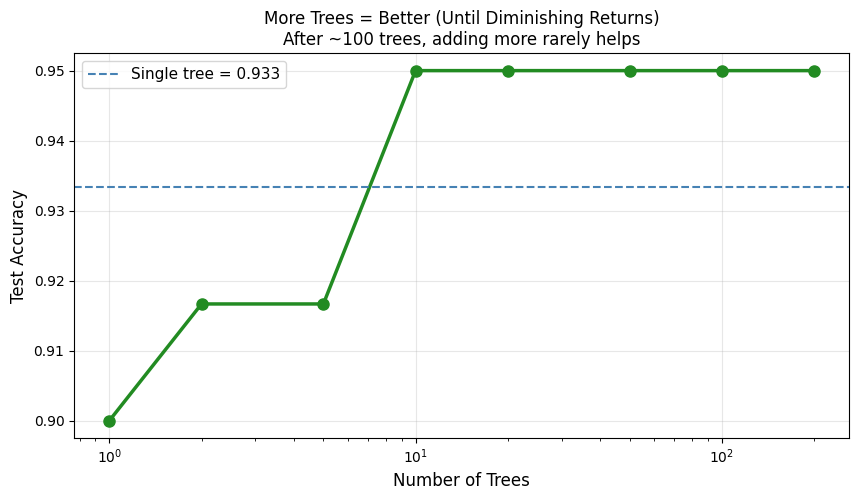

In [ ]:
# ── Part 2: Build a mini Random Forest from scratch ──
class RandomForestFromScratch:
    """
    Random Forest = Bagging + Feature Subsampling + Voting
    """
    def __init__(self, n_trees=10, max_depth=5,
                 max_features='sqrt', random_state=42):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
        self.feature_indices_list = []
        np.random.seed(random_state)

    def _get_n_features(self, n_total):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_total)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(n_total)))
        return n_total

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_select = self._get_n_features(n_features)

        for i in range(self.n_trees):
            # STEP 1: Bootstrap sample (with replacement)
            idx = np.random.choice(n_samples,
                                    size=n_samples, replace=True)
            X_boot, y_boot = X[idx], y[idx]

            # STEP 2: Random feature subset
            feat_idx = np.random.choice(n_features,
                                         size=n_select, replace=False)
            self.feature_indices_list.append(feat_idx)

            # STEP 3: Train a tree on this bootstrap + feature subset
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth, random_state=i)
            tree.fit(X_boot[:, feat_idx], y_boot)
            self.trees.append(tree)

        return self

    def predict(self, X):
        # STEP 4: Each tree votes — majority wins
        all_predictions = np.array([
            tree.predict(X[:, feat_idx])
            for tree, feat_idx in zip(self.trees,
                                       self.feature_indices_list)
        ])
        # Majority vote for each sample
        return np.apply_along_axis(
            lambda votes: np.bincount(votes).argmax(),
            axis=0,
            arr=all_predictions
        )

# ── Test: does more trees always help? ──
scratch_rf = RandomForestFromScratch(n_trees=50, max_depth=5)
scratch_rf.fit(X_train, y_train)
rf_preds = scratch_rf.predict(X_test)
print(f"\n🌲 Random Forest (scratch, 50 trees): "
      f"{accuracy_score(y_test, rf_preds):.4f}")

# Show how accuracy improves with more trees
n_trees_range = [1, 2, 5, 10, 20, 50, 100, 200]
rf_accuracies = []
for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    rf_accuracies.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_range, rf_accuracies, 'o-',
         color='forestgreen', linewidth=2.5, markersize=8)
plt.axhline(accuracy_score(y_test, sklearn_preds),
            color='steelblue', linestyle='--',
            label=f'Single tree = {accuracy_score(y_test, sklearn_preds):.3f}')
plt.xscale('log')
plt.xlabel("Number of Trees", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("More Trees = Better (Until Diminishing Returns)\n"
          "After ~100 trees, adding more rarely helps", fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

the class:

__init__: n_trees-how many trees to grow, max_depth=how tall each tree can get, max_features='sqrt'=how many features each tree sees. The trees list stores every trained tree, and feature_indices_list remebers whihc features each tree was trained on.

_get_n_features: the blinder rule, if you have 20 features and use 'sqrt', each tree only sees √20 ≈ 4 features. This is the secret sauce, by forcing each tree to be slightly blind, you prevent all trees from learning the same patterns and becoming copies of eachother.

fit: training loop(the forest grows), for each of the N trees it does three things in order, 1. draws a bootstrap sample, randomly pick 1000 rows from your 1000-row dataset, but with replacement,(so no rows appear twice, some not at all). 2. it picks a random subset of features. 3. it trains DecisionTreeClassifier on that combination. the tree and its feature list get stored.

predict: every tree votes on every test sample. np.bincount(votes).argmax() counts votes for each class and returns the winner.

The plot at the bottom tests does more trees= better accuracy? yes but with dminishing returns. Going from 1-10 trees is huge jump. Going from 100-200 trees barely moves the needle. the horizontal dashed line shows a single tree's accuracy so you can see how much the forest helps.

A random forest is just democracy applied to decision trees, each tree votes, majority wins, and making each voter slightly different(diff rows+diff features) is what makes the crowd smarter than any individual.

**Gradient Boosting-Learning from your mistakes**

Each new tree focuses on the mistakes of all previous trees combined. The mistakes are called residuals(the difference between prediction and truth)

Why gradients? because we find the mistakes by computing the gradient of the loss function, which for MSE loss literally equals the residual. For other loss functions, the gradient generalizes the concept of mistake.

Gradient Boosting=sequential trees where each tree corrects the error of all the previous trees.

🚀 GRADIENT BOOSTING — STEP BY STEP
Starting prediction (mean): 0.1735
Starting MSE: 0.4877

After tree  1: MSE = 0.429037  (residual std = 0.6983)
After tree  2: MSE = 0.378842  (residual std = 0.6550)
After tree  5: MSE = 0.276384  (residual std = 0.5525)
After tree 10: MSE = 0.185833  (residual std = 0.4520)
After tree 50: MSE = 0.027690  (residual std = 0.1680)


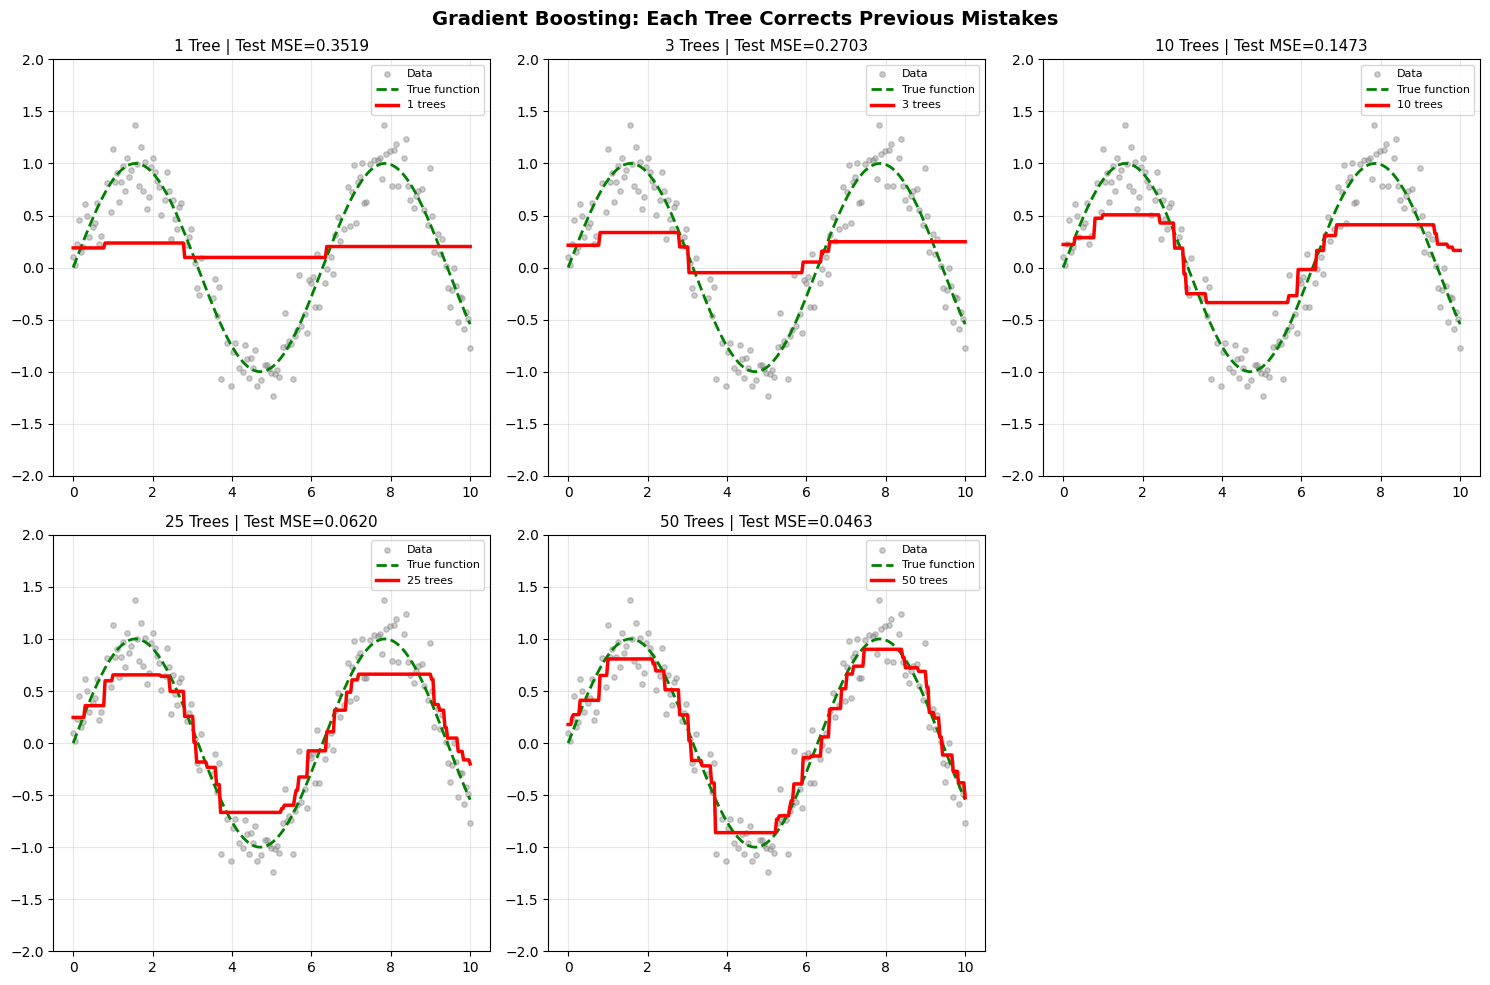

In [ ]:
# ── Gradient Boosting from scratch (conceptually) ──
print("🚀 GRADIENT BOOSTING — STEP BY STEP")
print("=" * 55)

# Use simple regression to make it crystal clear
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
# True function: noisy sine wave
X_gb = np.linspace(0, 10, 200).reshape(-1, 1)
y_gb = np.sin(X_gb.ravel()) + np.random.normal(0, 0.2, 200)

X_gb_train, X_gb_test, y_gb_train, y_gb_test = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42)

class GradientBoostingFromScratch:
    """
    Gradient Boosting for regression.
    Crystal clear implementation — read every line.
    """
    def __init__(self, n_trees=50, learning_rate=0.1 #each tree is one step down the loss surface,
                 max_depth=2 #shallow trees are intentionally weak leaners.
                 #A fully grown tree would just memorize the residuals perfectly, that is overfitting
                 #shallow trees generalize: they capture the main pattern of the current mistakes without memorizing noise

                 ):
        self.n_trees = n_trees
        self.lr = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.initial_prediction = None

    def fit(self, X, y):
        # STEP 1: Start with a constant prediction (mean of y)
        # This is our "dumb baseline"
        self.initial_prediction = np.mean(y)
        current_prediction = np.full(len(y), self.initial_prediction)

        print(f"Starting prediction (mean): {self.initial_prediction:.4f}")
        print(f"Starting MSE: {np.mean((y - current_prediction)**2):.4f}")
        print()

        for i in range(self.n_trees):
            # STEP 2: Compute RESIDUALS
            # = How wrong are we right now?
            # For MSE loss, residual = negative gradient = y - prediction
            residuals = y - current_prediction

            # STEP 3: Fit a shallow tree TO THE RESIDUALS
            # The tree learns to predict our current mistakes
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            self.trees.append(tree)

            # STEP 4: Update prediction
            # Small step (learning_rate) in the direction that reduces error
            update = tree.predict(X)
            current_prediction += self.lr * update

            if i in [0, 1, 4, 9, 49]:
                mse = np.mean((y - current_prediction)**2)
                print(f"After tree {i+1:2d}: MSE = {mse:.6f}  "
                      f"(residual std = {residuals.std():.4f})")

        return self

    def predict(self, X):
      #To predict on new data, start from the initial mean, then add each tree's
      #small contribution one by one.The 50 trees stack up into a surprisingly
      #accurate curve.
        prediction = np.full(len(X), self.initial_prediction)
        for tree in self.trees:
            prediction += self.lr * tree.predict(X)
        return prediction

gb_scratch = GradientBoostingFromScratch(
    n_trees=50, learning_rate=0.1, max_depth=2)
gb_scratch.fit(X_gb_train, y_gb_train)

# Visualise: how predictions improve over iterations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
n_trees_to_show = [1, 3, 10, 25, 50]
axes_flat = axes.ravel()

for ax, n in zip(axes_flat[:5], n_trees_to_show):
    gb_partial = GradientBoostingFromScratch(
        n_trees=n, learning_rate=0.1, max_depth=2)
    # Suppress print for partial models
    import io, sys
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    gb_partial.fit(X_gb_train, y_gb_train)
    sys.stdout = old_stdout

    X_plot = np.linspace(0, 10, 300).reshape(-1,1)
    y_plot_pred = gb_partial.predict(X_plot)
    y_plot_true = np.sin(X_plot.ravel())

    ax.scatter(X_gb_train, y_gb_train,
               alpha=0.4, s=15, color='gray', label='Data')
    ax.plot(X_plot, y_plot_true, 'g--',
            linewidth=2, label='True function')
    ax.plot(X_plot, y_plot_pred, 'r-',
            linewidth=2.5, label=f'{n} trees')
    mse = np.mean((y_gb_test - gb_partial.predict(X_gb_test))**2)
    ax.set_title(f"{n} Tree{'s' if n>1 else ''} | Test MSE={mse:.4f}",
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 2)
    ax.grid(alpha=0.3)

axes_flat[5].axis('off')
plt.suptitle("Gradient Boosting: Each Tree Corrects Previous Mistakes",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Instead of training trees in parallel(like RF), it trains them in sequence, where each new tree is specifically taught to fix the current mistakes.

with 1 tree prediction is a rough flat step function, by 50 trees it becomes a smooth curve that closely follows the sine wave. Each tree adds one more wiggle of detail.

Model                                 Test Acc      AUC    CV Mean
-----------------------------------------------------------------
Decision Tree (max_depth=5)             0.9211   0.9163     0.9319
Decision Tree (unlimited depth)         0.9123   0.9157     0.9099
Random Forest (100 trees)               0.9561   0.9939     0.9538
Gradient Boosting (sklearn)             0.9561   0.9907     0.9560


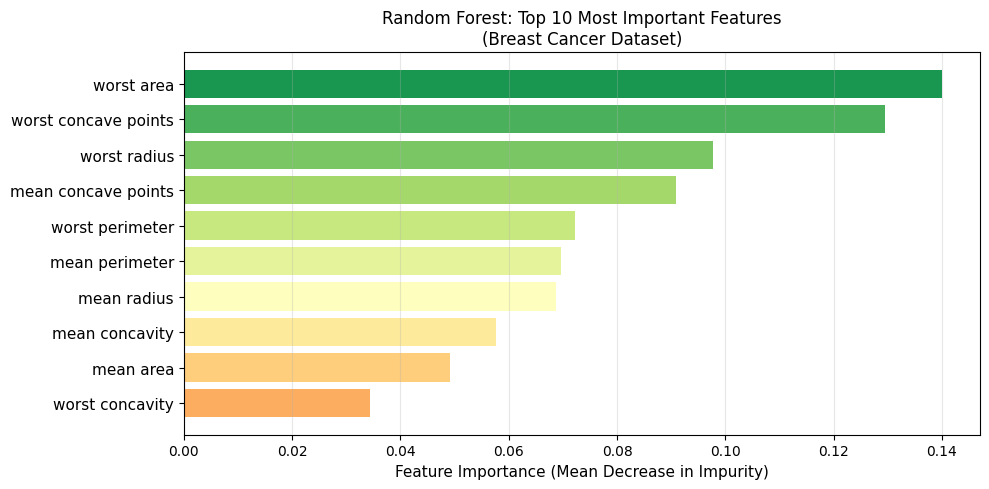


🔑 KEY INSIGHT:
Random Forest is robust and hard to overfit badly.
Gradient Boosting is more powerful but needs careful tuning.
XGBoost/LightGBM add: regularisation, missing value handling,
histogram-based splitting, and massive speed improvements.


In [ ]:
#XGBoost vs LightGBM — Why They Dominate Competitions
#The Core Improvements Over Basic GBM:
# ── Compare all tree methods on a real dataset ──
data = load_breast_cancer()#load the whole dataset
X_real, y_real = data.data, data.target #X=features, Y= labels

X_tr, X_te, y_tr, y_te = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)
# random_state=42 gives same split in every run
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr) #learn mean/std, then scale
X_te_s = scaler.transform(X_te)#scale using same mean/std

# All tree models side by side
models = {
    'Decision Tree\n(max_depth=5)':
        DecisionTreeClassifier(max_depth=5, random_state=42),
    'Decision Tree\n(unlimited depth)':
        DecisionTreeClassifier(random_state=42),
    'Random Forest\n(100 trees)':
        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting\n(sklearn)':
        GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Model':<35} {'Test Acc':>10} {'AUC':>8} {'CV Mean':>10}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_tr_s, y_tr)
    preds  = model.predict(X_te_s)
    probas = model.predict_proba(X_te_s)[:, 1]
    acc    = accuracy_score(y_te, preds)
    auc    = roc_auc_score(y_te, probas)
    cv     = cross_val_score(model, X_tr_s, y_tr, cv=5).mean()
    results[name] = {'acc': acc, 'auc': auc, 'cv': cv}
    clean_name = name.replace('\n', ' ')
    print(f"{clean_name:<35} {acc:>10.4f} {auc:>8.4f} {cv:>10.4f}")

# Feature importance from Random Forest
rf_model = models['Random Forest\n(100 trees)']
importances = rf_model.feature_importances_
feat_names  = data.feature_names
top_idx     = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))
plt.barh(range(10),
         importances[top_idx[::-1]],
         color=colors)
plt.yticks(range(10), feat_names[top_idx[::-1]], fontsize=11)
plt.xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
plt.title("Random Forest: Top 10 Most Important Features\n"
          "(Breast Cancer Dataset)", fontsize=12)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🔑 KEY INSIGHT:")
print("Random Forest is robust and hard to overfit badly.")
print("Gradient Boosting is more powerful but needs careful tuning.")
print("XGBoost/LightGBM add: regularisation, missing value handling,")
print("histogram-based splitting, and massive speed improvements.")


acc(accuracy)=out of all predictions, how many were right?, good for balanced datasets.

auc(ROC AUC)=how good is the model at ranking cancer vs non-cancer?

cv(cross-val)=does it perform consistently, or did it just get lucky on one test split?

**XGBoost and LightGBM**

They are both boosted trees.

**XGBoost**

Extreme Gradient Boosting, took the basic boosting idea and made it smarter.

It adds a penalty for complexity, the model is mathematically punished for making trees too complicated. This prevents memorizing teh training data.

It can handle missing values natively, no need to fill in gaps yourself.

It uses all CPU cores in parallel.sklearn's version uses just 1 core.

**LightGBM**

Light Gradient Boosting Machine, same boosting idea but engineered for speed

The key trick: instaed of checking every possible split value, it groups values into ~256 buckets(a histogram). Searching 256 options vs 1,000,000=massively faster.

On big datasets(millions of rows), LightGBM can be 10-100x faster than XGBoost with similar accuracy.

Also supports GPU training and handles missing values natively.

XGBoost vs LightGBM — when to use which?

XGBoost
* Dataset fits in RAM (up to ~1M rows)
* You want maximum interpretability of hyperparameters
* Lots of community resources + tutorials
* More battle-tested in production

LightGBM ← start here
* Large datasets (1M+ rows)
* Want fast iteration during tuning
* Kaggle competitions (popular default)
* Memory constrained environment

Both XGBoost ang LighGBM are just upgraded versions of gradient boosting, the same "each tree fixes the previous tree's mistakes". The upgrade is not about a new idea, it is about engineering: faster training (parallel CPUs, GPU, histogram bucketing), built-in missing value handling, and a math penalty that stops the model from overfitting.

XGBoost = GBM + math penalties for complexity + handles missing data.
LightGBM = XGBoost + histogram bucketing + smarter tree growth = same accuracy, way faster.
